# HyPhy Omega Distribution Plots

Generates omega distribution plots found in [Fig. 2](figures/figure_2), [Fig. 3](figures/figure_3), and [Fig. 4](figures/figure_4)

## Notebook Workflow

1. Load cached HyPhy result objects (RELAX and BUSTED variants).
2. Filter extreme omega outliers for stable visual summaries.
3. Generate omega distribution plots for each analysis branch.
4. Export publication-ready omega figure panels to the figures directory.

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=SyntaxWarning)

In [19]:
import sys
import os
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None, 'display.max_rows', 50)

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage03_path = os.path.join(repo_root, "scripts", "03_selection_tests")
stage06_path = os.path.join(repo_root, "scripts", "06_figures_tables")
for path in (src_path, stage03_path, stage06_path):
    if path not in sys.path:
        sys.path.append(path)

print(f"Using src path: {src_path}")
print(f"Using stage-03 path: {stage03_path}")
print(f"Using stage-06 path: {stage06_path}")

from hyphy_results_parser import (
    RelaxResult,
    BustedPhResult
)
from omega_plots import plot_omega_distributions, plot_omega_single_gene

figures = os.path.join(repo_root, "figures")
hyphy_results = os.path.join(repo_root, "results", "hyphy_results_cache")

Using src path: /Users/calvin/orb-selection/src
Using stage-03 path: /Users/calvin/orb-selection/scripts/03_selection_tests
Using stage-06 path: /Users/calvin/orb-selection/scripts/06_figures_tables


In [4]:
%load_ext autoreload


In [5]:
# Load the saved RELAX results
relax_result = RelaxResult.load_from_pickle(os.path.join(hyphy_results, "relax_results.pkl"))

# Load the saved BUSTED-PH results
busted_ph_result = BustedPhResult.load_from_pickle(os.path.join(hyphy_results, "busted_ph_results.pkl"))

# Load the saved BUSTED-PH-REV results
busted_ph_rev_result = BustedPhResult.load_from_pickle(os.path.join(hyphy_results, "busted_ph_rev_results.pkl"))

Filter out extremely large omega values from the results (arbitrary threshold of 10,000)

In [6]:
relax_result_fltrd = relax_result.filter_omega(10000)
busted_ph_result_fltrd = busted_ph_result.filter_omega(10000)
busted_ph_rev_result_fltrd = busted_ph_rev_result.filter_omega(10000)

In [7]:
relax_df_fltrd = relax_result_fltrd.results_df
busted_ph_df_fltrd = busted_ph_result_fltrd.results_df
busted_ph_rev_df_fltrd = busted_ph_rev_result_fltrd.results_df

## Omega plots

(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

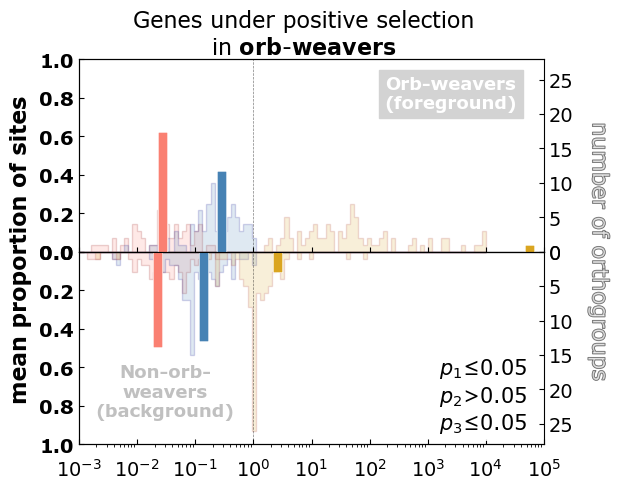

In [8]:
x=busted_ph_df_fltrd[busted_ph_df_fltrd['result']=='hit']
result='busted'
top_title = 'Orb-weavers\n(foreground)'
bottom_title = 'Non-orb-\nweavers\n(background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under positive selection\nin "+ r'$\bf{orb}$'+ "-" + r'$\bf{weavers}$',
    # filename=os.path.join(figures, 'figure_4/busted_ph_omega_dist.png'),
    transparent=True
    )

(<Figure size 600x500 with 5 Axes>, array([<Axes: >, <Axes: >], dtype=object))

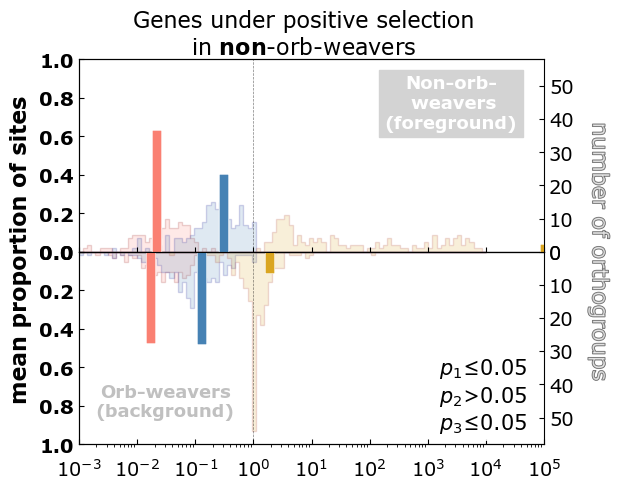

In [9]:
x=busted_ph_rev_df_fltrd[busted_ph_rev_df_fltrd['result']=='hit']
result='busted'
top_title = 'Non-orb-\n weavers\n(foreground)'
bottom_title = 'Orb-weavers\n(background)'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under positive selection\nin " + r'$\bf{non}$' + "-orb-weavers",
    # filename=os.path.join(figures, 'figure_4/busted_ph_rev_omega_dist.png'),
    transparent=True,
    shift_top_title=True
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

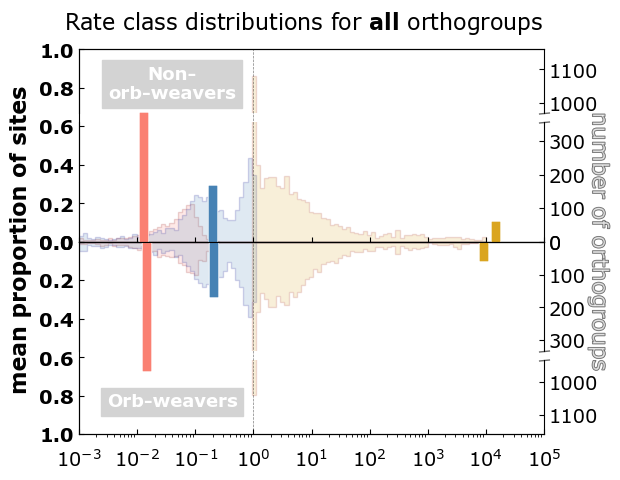

In [10]:
x=relax_df_fltrd

result='all'
top_title = 'Non-\norb-weavers'
bottom_title = 'Orb-weavers'

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Rate class distributions for " + r"$\bf{all}$" + " orthogroups",
    # filename=os.path.join(figures, 'figure_2/relax_all_omega_dist.png'),
    transparent=False
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

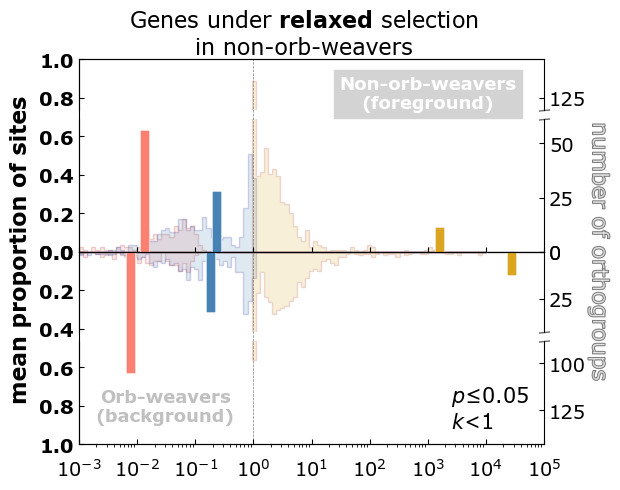

In [11]:
x=relax_df_fltrd[relax_df_fltrd['result']=='relaxed']
result='relaxed'
top_title = 'Non-orb-weavers\n(foreground)' 
bottom_title = 'Orb-weavers\n(background)' 

plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title,
    suptitle="Genes under " + r"$\bf{relaxed}$" + " selection\nin non-orb-weavers", 
    # filename=os.path.join(figures, 'figure_3/relax_relaxed_omega_dist.png'),
    transparent=True
    )

(<Figure size 600x500 with 11 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       dtype=object))

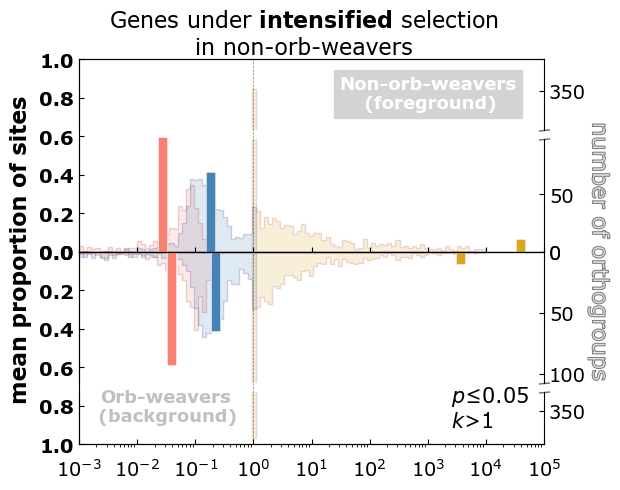

In [12]:
x=relax_df_fltrd[relax_df_fltrd['result']=='intensified']
result='intensified'
top_title = 'Non-orb-weavers\n (foreground)'
bottom_title = 'Orb-weavers\n (background)'

%autoreload 2
plot_omega_distributions(
    x, 
    result, 
    top_title, 
    bottom_title, 
    suptitle="Genes under " + r"$\bf{intensified}$" + " selection\nin non-orb-weavers", 
    # filename=os.path.join(figures, 'figure_3/relax_intensified_omega_dist.png'),
    transparent=True
)

Plot example genes from each selection pattern

(<Figure size 550x500 with 1 Axes>, <Axes: >)

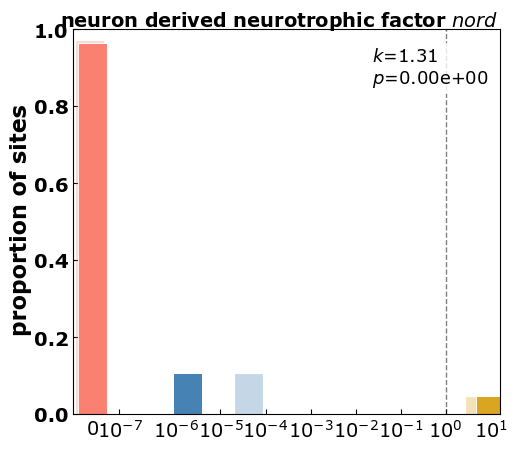

In [28]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0061683', 
    'neuron derived neurotrophic factor $\it{nord}$',  
    offset_zero=True, 
    k=True,
    # filename=str(figures + 'figure_2/relax_nord_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

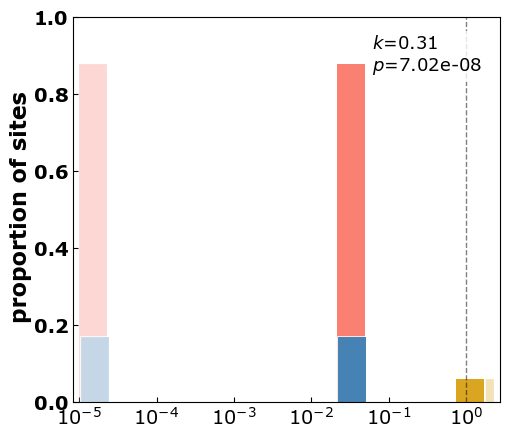

In [23]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0066983', 
    k=True,
    # filename=os.path.join(figures, 'figure_3/relax_acetylcholine_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

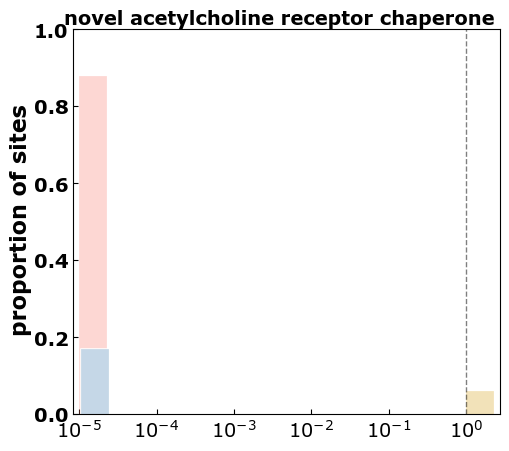

In [ ]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0066983', 
    suptitle='novel acetylcholine receptor chaperone',
    k=True,
    filename=str(figures + 'figure_3/relax_acetylcholine_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

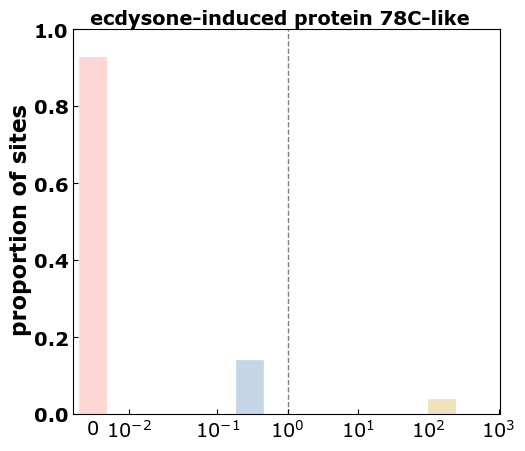

In [ ]:
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0048857', 
    suptitle = 'ecdysone-induced protein 78C-like', 
    k=True,
    filename=str(figures + 'figure_3/relax_ecdysone_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

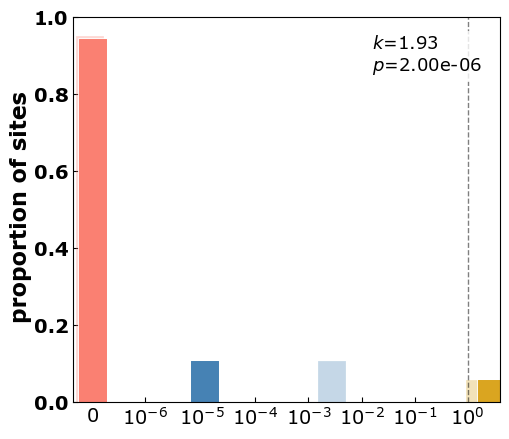

In [35]:
%autoreload 2
plot_omega_single_gene(
    relax_df_fltrd, 
    'N5.HOG0037767', 
    # suptitle = 'ecdysone-induced protein 78C-like', 
    offset_zero=True, 
    k=True,
    filename=os.path.join(figures, 'figure_3/relax_ecdysone_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

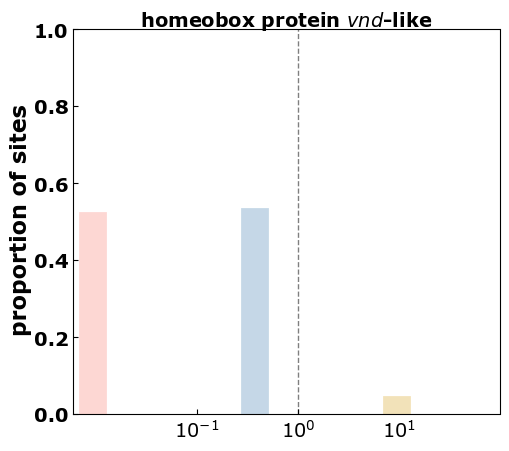

In [ ]:
plot_omega_single_gene(
    busted_ph_df_fltrd, 
    'N5.HOG0069577', 
    suptitle='  homeobox protein $\it{vnd}$-like',
    filename=str(figures + 'figure_4/busted_ph_hox_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

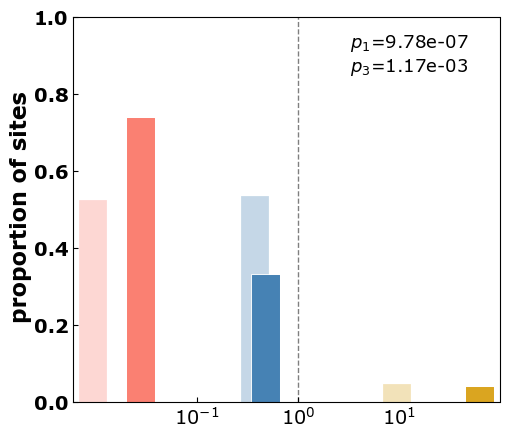

In [ ]:
plot_omega_single_gene(
    busted_ph_df_fltrd, 
    'N5.HOG0069577', 
    # suptitle='  homeobox protein $\it{vnd}$-like',
    filename=str(figures + 'figure_4/busted_ph_hox_omega_plot.png'),
    transparent=False
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

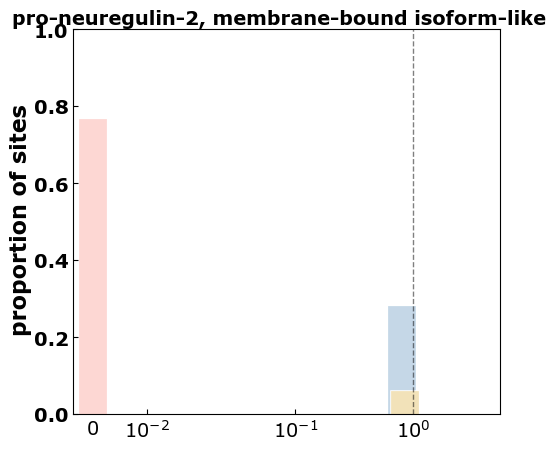

In [ ]:
plot_omega_single_gene(
    busted_ph_rev_df_fltrd, 
    'N5.HOG0028049', 
    suptitle='pro-neuregulin-2, membrane-bound isoform-like',
    filename=str(figures + 'figure_4/busted_ph_proneuregulin_omega_plot_bg_only.png'),
    transparent=False,
    build_in=True
    )

(<Figure size 550x500 with 1 Axes>, <Axes: >)

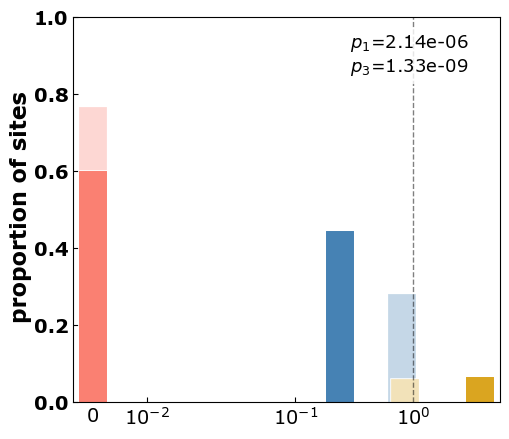

In [ ]:
plot_omega_single_gene(
    busted_ph_rev_df_fltrd, 
    'N5.HOG0028049', 
    # suptitle='pro-neuregulin-2, membrane-bound isoform-like',
    filename=str(figures + 'figure_4/busted_ph_proneuregulin_omega_plot.png'),
    transparent=False
    )